# ERP CORE N170 (face perception) dataset exploration

*Auxiliary notebook for the QMN TA team (signal-processing weeks 10-13)*

Loads the reduced ERP CORE N170 package (`notebooks/data/erpcore_n170.npz`) and checks whether it can carry an event-related-potential
(ERP) practical to complement the resting-state alpha dataset.

**Why this dataset.** The alpha dataset shows an *endogenous rhythm* in the *frequency domain*.
This one is its natural counterpart: a *stimulus-evoked response* in the *time domain*. The
**N170** is a negative deflection ~150 ms over occipito-temporal electrodes (PO7/PO8), classically
associated with face processing (from Kappenman & Luck's ERP CORE).

**The contrast used here: face vs scrambled-face.** A phase-scrambled face carries the same
low-level image statistics as the intact one but is not a face, so the subtraction isolates
face-specific processing and gives a clear amplitude effect. The package also holds car and
scrambled-car epochs, which this notebook leaves aside.

**Package contents** (pre-processed build-time with MNE; documented in
`notebooks/data/eeg_datadictionary.md`):
band-pass 0.5-30 Hz, average reference, epochs -0.2..0.8 s, 250 uV rejection, resampled to 256 Hz,
6 curated subjects, 30 EEG channels, amplitudes in microvolts, four conditions.

In [1]:
# --- Imports + plot style (numpy/scipy/matplotlib only - no MNE needed here)
# the notebooks/ folder, so the paths below work wherever this is opened from
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

d = np.load(ROOT / "data" / "erpcore_n170.npz", allow_pickle=True)
X        = d["X"]                       # (n_epochs, n_channels, n_times) microvolts
cond     = d["condition"]              # face / car / scrambled_face / scrambled_car
subject  = d["subject"]               # subject id per epoch
times    = d["times"]                 # seconds, relative to stimulus onset
ch_names = list(d["ch_names"])
ch_xy    = d["ch_xy"]                  # top-down topography coordinates
fs       = float(d["sfreq"])

def ci(name): return ch_names.index(name)
oc = [ci("PO7"), ci("PO8")]            # the occipito-temporal N170 sites
subs = sorted(set(subject))

def wave(mask):
    "Grand-average waveform at PO7/PO8 for the epochs selected by `mask`."
    return X[mask][:, oc, :].mean(axis=(0, 1))

print("epochs:", X.shape[0], "| channels:", X.shape[1], "| samples:", X.shape[2])
print("conditions:", {c: int((cond == c).sum()) for c in sorted(set(cond))})
print("subjects:", subs)


epochs: 1733 | channels: 30 | samples: 256
conditions: {np.str_('car'): 435, np.str_('face'): 426, np.str_('scrambled_car'): 435, np.str_('scrambled_face'): 437}
subjects: [np.str_('sub-001'), np.str_('sub-002'), np.str_('sub-004'), np.str_('sub-005'), np.str_('sub-006'), np.str_('sub-007')]


## 1. Averaging pulls the ERP out of the noise

A single-trial EEG sweep is dominated by ongoing background activity - you cannot see the evoked
response in any one trial. Averaging many trials time-locked to stimulus onset cancels the
(unrelated) background and leaves the part that is consistent across trials. Below: ~30 single face
trials at PO8 (thin grey) with their average on top. The evoked response only appears in the average.

*Teaching hook: event alignment + the core ERP idea that noise falls as ~1/sqrt(n_trials).*


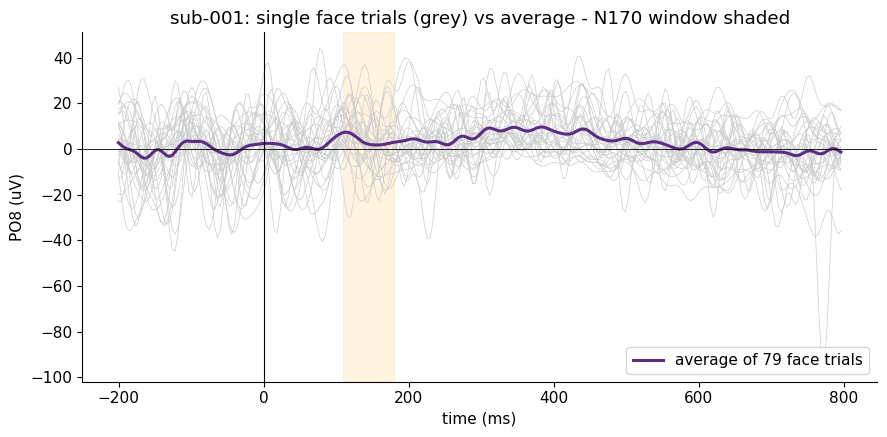

In [2]:
# --- Single trials vs their average at PO8 (one subject)
s0 = subs[0]
po8 = X[(subject == s0) & (cond == "face"), ci("PO8"), :]
fig, ax = plt.subplots(figsize=(9, 4.5))
for tr in po8[:30]:
    ax.plot(times * 1000, tr, color="0.8", lw=0.5)
ax.plot(times * 1000, po8.mean(0), color="#5b2c83", lw=2.2, label=f"average of {len(po8)} face trials")
ax.axvline(0, color="k", lw=0.8); ax.axhline(0, color="k", lw=0.6)
ax.axvspan(110, 180, color="orange", alpha=0.12)
ax.set_xlabel("time (ms)"); ax.set_ylabel("PO8 (uV)")
ax.set_title(f"{s0}: single face trials (grey) vs average - N170 window shaded")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


## 2. face vs scrambled-face: the N170 amplitude effect

Comparing intact faces with their phase-scrambled versions (same low-level image statistics, no
face) isolates face-specific processing, and gives a clear amplitude effect: faces are markedly
more negative around 150 ms.

*Teaching hook: choosing the right control condition, and reading an amplitude effect off a
grand-average waveform.*

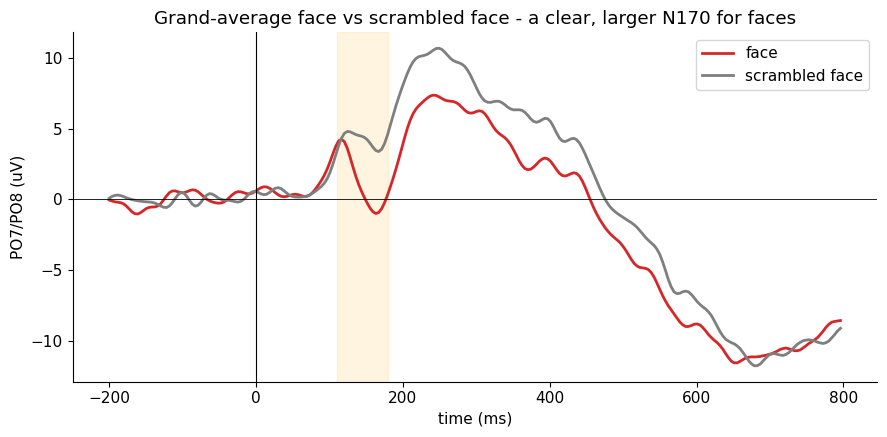

AMPLITUDE 110-180 ms: face 0.95 uV vs scrambled 4.21 uV -> face more negative by 3.26 uV in 6/6 subjects


In [3]:
# --- Grand-average face vs scrambled-face at PO7/PO8
win = (times >= 0.110) & (times <= 0.180)      # the N170 measurement window, shaded below
def mean_amp(w): return w[win].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(times * 1000, wave(cond == "face"),           color="#d62728", lw=2, label="face")
ax.plot(times * 1000, wave(cond == "scrambled_face"), color="#7f7f7f", lw=2, label="scrambled face")
ax.axvline(0, color="k", lw=0.8); ax.axhline(0, color="k", lw=0.6)
ax.axvspan(110, 180, color="orange", alpha=0.12)
ax.set_xlabel("time (ms)"); ax.set_ylabel("PO7/PO8 (uV)")
ax.set_title("Grand-average face vs scrambled face - a clear, larger N170 for faces")
ax.legend(); plt.tight_layout(); plt.show()

fa = np.array([mean_amp(wave((subject == s) & (cond == "face")))           for s in subs])
sf = np.array([mean_amp(wave((subject == s) & (cond == "scrambled_face"))) for s in subs])
print("AMPLITUDE 110-180 ms: face %.2f uV vs scrambled %.2f uV -> face more negative by %.2f uV in %d/%d subjects"
      % (fa.mean(), sf.mean(), (sf - fa).mean(), int((fa < sf).sum()), len(subs)))

## 3. The difference wave

Subtracting one condition from the other is the standard way to isolate an ERP effect. Taking the
difference **within each subject** and then averaging gives the mean difference wave with a
standard error across subjects, so the figure shows both how big the effect is and how consistent
it is from one participant to the next.

*Teaching hook: difference waves, within-subject subtraction, SEM across subjects.*

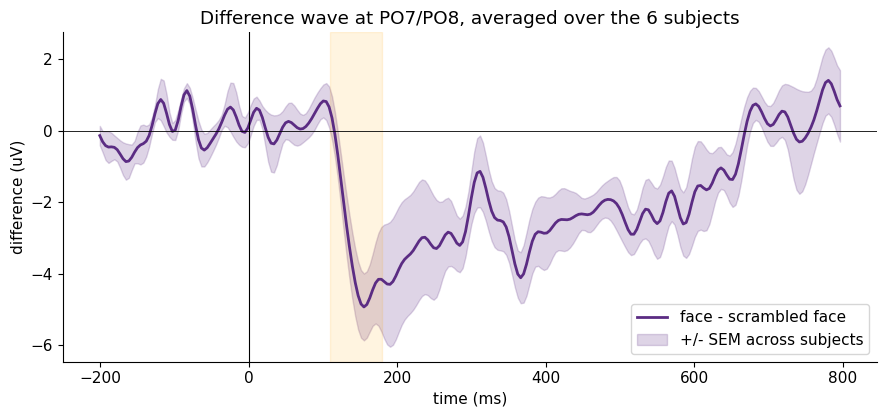

In [4]:
# --- The face - scrambled difference wave (per-subject mean +/- SEM)
dd = np.array([wave((subject == s) & (cond == "face"))
               - wave((subject == s) & (cond == "scrambled_face")) for s in subs])
m, se = dd.mean(0), dd.std(0, ddof=1) / np.sqrt(len(subs))

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(times * 1000, m, color="#5b2c83", lw=2, label="face - scrambled face")
ax.fill_between(times * 1000, m - se, m + se, color="#5b2c83", alpha=0.2,
                label="+/- SEM across subjects")
ax.axvline(0, color="k", lw=0.8); ax.axhline(0, color="k", lw=0.6)
ax.axvspan(110, 180, color="orange", alpha=0.12)
ax.set_xlabel("time (ms)"); ax.set_ylabel("difference (uV)")
ax.set_title("Difference wave at PO7/PO8, averaged over the 6 subjects")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 4. Scalp topography of the N170 (face minus scrambled)

Where on the scalp is the effect? Mean amplitude per channel in the N170 window (110-180 ms) for
faces, scrambled faces, and their difference, drawn at approximate 10-20 positions. The face-minus-scrambled map is focal over occipito-temporal
sites (PO7/PO8).

*Teaching hook: spatial topography, dipolar scalp patterns, choosing electrodes from the map.*


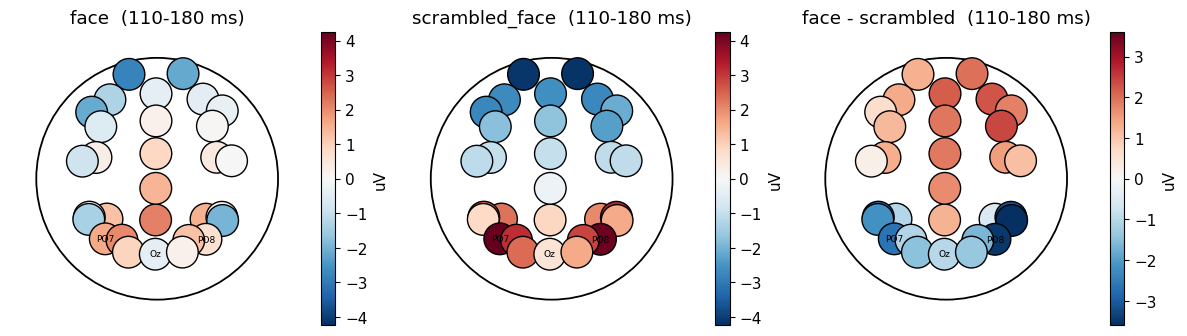

In [5]:
# --- Topography in the N170 window (110-180 ms): face, scrambled, difference
amp = {c: X[cond == c][:, :, win].mean(axis=(0, 2)) for c in ["face", "scrambled_face"]}
amp["face - scrambled"] = amp["face"] - amp["scrambled_face"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.4))
vmax = np.abs(amp["face - scrambled"]).max()
for ax, key in zip(axes, ["face", "scrambled_face", "face - scrambled"]):
    v = amp[key]
    lim = vmax if key == "face - scrambled" else np.abs(
        np.concatenate([amp["face"], amp["scrambled_face"]])).max()
    sc = ax.scatter(ch_xy[:, 0], ch_xy[:, 1], c=v, s=520, cmap="RdBu_r",
                    vmin=-lim, vmax=lim, edgecolor="k", zorder=2)
    for j, nm in enumerate(ch_names):
        if nm in ("PO7", "PO8", "Oz"):
            ax.annotate(nm, ch_xy[j], ha="center", va="center", fontsize=6.5, zorder=3)
    ax.add_patch(plt.Circle((0, 0), 1.15, fill=False, lw=1.3))
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(key + "  (110-180 ms)")
    fig.colorbar(sc, ax=ax, fraction=0.045, label="uV")
plt.tight_layout(); plt.show()


## 5. Is it there in each subject?

Per-subject N170 mean amplitude (110-180 ms at PO7/PO8) for faces vs scrambled faces. In a clean
dataset every subject's face bar is more negative.

*Teaching hook: individual variability, within-subject paired effects, hook back to the stats weeks.*


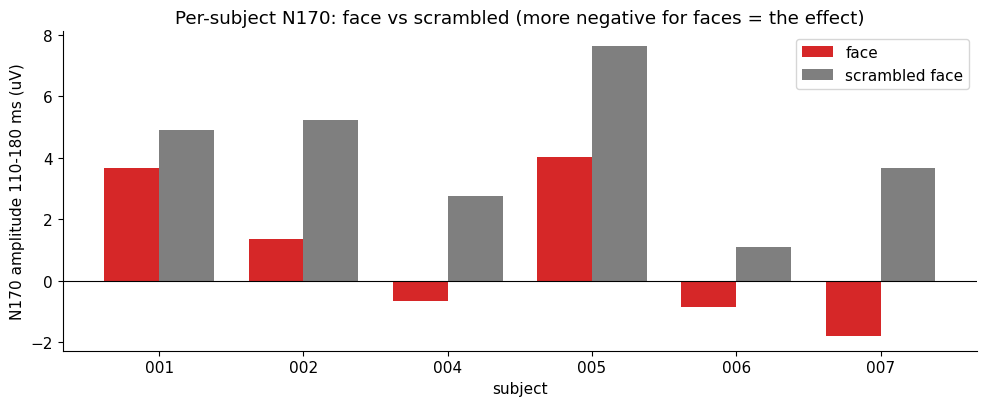

subjects with face more negative than scrambled: 6/6
mean face - scrambled: -3.26 uV


In [6]:
# --- Per-subject face vs scrambled amplitude
faceA = np.array([X[(subject == s) & (cond == "face")][:, oc, :][:, :, win].mean() for s in subs])
scrA  = np.array([X[(subject == s) & (cond == "scrambled_face")][:, oc, :][:, :, win].mean() for s in subs])
x = np.arange(len(subs)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(x - w/2, faceA, w, color="#d62728", label="face")
ax.bar(x + w/2, scrA,  w, color="#7f7f7f", label="scrambled face")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([s.replace("sub-", "") for s in subs])
ax.set_xlabel("subject"); ax.set_ylabel("N170 amplitude 110-180 ms (uV)")
ax.set_title("Per-subject N170: face vs scrambled (more negative for faces = the effect)")
ax.legend(); plt.tight_layout(); plt.show()
print("subjects with face more negative than scrambled: %d/%d" % (int((faceA < scrA).sum()), len(subs)))
print("mean face - scrambled: %.2f uV" % (faceA - scrA).mean())


## What this dataset can teach

| Technique | Section | Content |
|---|---|---|
| Event alignment + averaging (noise ~1/sqrt(n)) | 1 | Single-trial vs average is vivid |
| Condition choice + a real amplitude N170 | 2 | Faces clearly more negative, in 6/6 subjects |
| Difference waves, within-subject subtraction | 3 | A standard ERP object, with SEM across subjects |
| Scalp topography | 4 | Focal occipito-temporal effect |
| Individual variability / paired effect | 5 | Hooks back to the stats weeks |

**Overall:** a clean, canonical ERP companion to the alpha dataset. The two are opposites in a
useful way: a time-domain evoked response here against a frequency-domain ongoing rhythm there,
both posterior, both loadable with numpy alone. Averaging is the right tool for this one and the
wrong one for the alpha blocks, which is the lesson the pairing exists to teach.
NB: this is a small 6-subject teaching subset of the 40-subject ERP CORE (CC BY-SA 4.0; credit
Kappenman & Luck, keep the same license).